# Question 1 : Linear Regression

In [29]:
# Libraries
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error

In [30]:
# Dataset Class from A1
class StudentDataset:
    """
        A class that generates and visualizes a student demographic.
        Parameters:
            num_students (int): The number of students to generate.
            seed (int): The random seed for reproducibility.
    """

    def __init__(self, num_students: int, seed: int, username: str):
        """
            Sets up the initial variables like num_students, seed and calls the data generation methods.
        """
        self.num_students = num_students
        self.seed = seed
        self.username = username
        np.random.seed(seed) # Set the deterministic seed generated based on username in the previous cell
        self.data = self.assemble_dataframe()

    def assemble_dataframe(self):
        """
            Assembles the full dataset from gender, major, program, and GPA.
            Returns:
                pd.DataFrame: A DataFrame containing the student demographic data.
        """
        
        gender = self.generate_gender()
        major = self.generate_major()
        program = self.generate_program(major)
        gpa = self.generate_gpa(major)

        data = {
            'Gender': gender,
            'Major': major,
            'Program': program,
            'GPA': gpa
        }

        return pd.DataFrame(data)

    def generate_gender(self) -> list[str]:
        """
            Generates a list of genders among {Male, Female, Other} with probabilities {0.65, 0.33, 0.02} respectively
            Returns:
                list[str]: A list of genders for the students.
        """

        genders = ["Male", "Female", "Other"]
        probs = [0.65, 0.33, 0.02]
        return np.random.choice(genders, size=self.num_students, p=probs).tolist()

    def generate_major(self) -> list[str]:
        """
            Generates a list of majors among {B.Tech, MS, PhD} with probabilities {0.7, 0.2, 0.1} respectively
            Returns:
                list[str]: A list of majors for the students.
        """

        majors = ["B.Tech", "MS", "PhD"]
        probs = [0.7, 0.2, 0.1]
        return np.random.choice(majors, size=self.num_students, p=probs).tolist()

    def generate_program(self, majors: list[str]) -> list[str]:
        """
            Generates a list of programs among {CSE, ECE, CHD, CND} conditioned on the major.
            Parameters:
                majors (list[str]): A list of majors for the students.
            Returns:
                list[str]: A list of programs for the students.
        """

        programs = []
        for major in majors:
            if major == "B.Tech":
                programs.append(np.random.choice(["CSE", "ECE", "CHD", "CND"], p=[0.4, 0.4, 0.1, 0.1]))
            elif major == "MS":
                programs.append(np.random.choice(["CSE", "ECE", "CHD", "CND"], p=[0.3, 0.3, 0.2, 0.2]))
            else:
                programs.append(np.random.choice(["CSE", "ECE", "CHD", "CND"], p=[0.25, 0.25, 0.25, 0.25]))

        return programs

    def generate_gpa(self, majors: list[str]) -> list[float]:
        """
            Generates a list of GPAs conditioned on the major. Values are clipped to [4.0, 10.0]
            Parameters:
                majors (list[str]): A list of majors for the students.
            Returns:
                list[float]: A list of GPAs for the students.
        """

        gpa = []
        for major in majors:
            if major == "B.Tech":
                gpa.append(np.clip(np.random.normal(7.0, 1.0), 4.0, 10.0))
            elif major == "MS":
                gpa.append(np.clip(np.random.normal(8.0, 0.49), 4.0, 10.0))
            else:
                gpa.append(np.clip(np.random.normal(8.3, 0.25), 4.0, 10.0))

        return gpa
        
    def get_full_dataframe(self) -> pd.DataFrame:
        """
            Returns the full DataFrame containing the student demographic data.
            Returns:
                pd.DataFrame: The DataFrame with student demographics.
        """
        return self.data

In [31]:
class PerFeatureTransformer:
    def __init__(self):
        """
            Initializes memory for per-feature transformers.
        """
        self.transformers = {}
        self.params = {}

    def fit(self, df: pd.DataFrame, params: dict[str, str])-> None:
        """
            Fits transformers for each feature based on the given type.
            Parameters:
                df: The dataframe containing features to be transformed.
                params: A dictionary mapping feature name to
                transformation type,
                e.g., {"GPA": "standard", "major": "ordinal", "program":
                "onehot"}.
        """
        self.params = params
        for feature, method in params.items():
            if method == "standard":
                scaler = StandardScaler()
                scaler.fit(df[[feature]]) # df[feature] is of shape (n,) and df[[feature]] is of shape (n, 1) which is expected by the scikit-learn transformer function
                self.transformers[feature] = scaler
                # print("Standard Scaler: ", scaler)
                # print("Mean: ", scaler.mean_)
                # print("Standard Deviation: ", scaler.var_)

            elif method == "ordinal":
                encoder = OrdinalEncoder()
                encoder.fit(df[[feature]])
                self.transformers[feature] = encoder
                # print("Ordinal Encoder: ", encoder)
                # print("Categories: ", encoder.categories_)

            elif method == "onehot":
                encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
                encoder.fit(df[[feature]])
                self.transformers[feature] = encoder
                # print("One-Hot Encoder: ", encoder)
                # print("Categories: ", encoder.categories_)

            else:
                raise ValueError(f"Error in transforming using {method} for feature {feature}")
            
    def transform(self, df: pd.DataFrame)-> np.ndarray:
        """
            Applies the fitted transformers to the corresponding features and returns a NumPy array.
            Parameters:
                df: The dataframe containing features to be transformed.
            Returns:
                A NumPy array containing the transformed features.
        """
        transformed_list = []
        for feature, method in self.params.items():
            transformer = self.transformers[feature]
            transformed = transformer.transform(df[[feature]])
            transformed_list.append(transformed)
        return np.hstack(transformed_list)

    def fit_transform(self, df: pd.DataFrame, params: dict[str, str])-> np.ndarray:
        """
            Fits and transforms all features in one step using the given transformation parameters.
            Parameters:
                df: The dataframe containing features to be transformed.
                params: A dictionary mapping feature name to transformation type.
            Returns:
                A NumPy array containing the transformed features.
        """
        self.fit(df, params)
        return self.transform(df)

In [32]:
class KNNGenderPredictor:

    def _add_username(self) -> None:
        plt.text(0.95, 0.4, self.username, ha="right", va="top", transform=plt.gca().transAxes, fontsize=10, color="gray", alpha=0.7)

    def __init__(self, student_df: pd.DataFrame, username: str, seed: int):
        """
            Initializes the KNNGenderPredictor with the student DataFrame.
            Parameters:
                student_df (pd.DataFrame): The DataFrame containing student data.
                username (str): The username for the plots.
                seed (int): The random seed for reproducibility.
        """
        self.df = student_df
        self.username = username
        self.seed = seed
        self.transformer = PerFeatureTransformer()
        self.X_train = self.X_val = self.X_test = None
        self.y_train = self.y_val = self.y_test = None

    def train_val_test_split(self, test_size: float = 0.2, val_size: float = 0.2):
        """
            Splits dataset into train, validation, and test sets.
            Parameters:
                test_size (float): The proportion of the dataset to include in the test split.
                val_size (float): The proportion of the training dataset to include in the validation split.
            Returns:
                Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]: The train, validation, and test DataFrames.
        """
        train_df, test_df = train_test_split(self.df, test_size=test_size, random_state=self.seed)
        train_df, val_df = train_test_split(train_df, test_size=val_size/(1-test_size), random_state=self.seed)
        # print("Training data and size")
        # print(train_df.head())
        # print(train_df.shape)
        # print("Validation data and size")
        # print(val_df.head())
        # print(val_df.shape)
        # print("Test data and size")
        # print(test_df.head())
        # print(test_df.shape)
        return train_df, val_df, test_df

    def get_feature_matrix_and_labels(self, df: pd.DataFrame, features: dict[str, str]):
        """
            Extract features and labels with transformations.
            Parameters:
                df (pd.DataFrame): The DataFrame from which to extract features and labels.
                features (dict[str, str]): A dictionary mapping feature names to their transformation types.
            Returns:
                Tuple[np.ndarray, np.ndarray]: The feature matrix X and the label array y.
        """
        X = self.transformer.fit_transform(df, features)
        y = df["GPA"].values
        return X, y

    def prepare_data(self, train_df: pd.DataFrame, val_df: pd.DataFrame, test_df: pd.DataFrame, params: dict[str, str]) -> None:
        """
            Prepares the data by extracting features and labels for train, validation, and test sets.
            Parameters:
                train_df (pd.DataFrame): The training DataFrame.
                val_df (pd.DataFrame): The validation DataFrame.
                test_df (pd.DataFrame): The test DataFrame.
                params (dict[str, str]): The parameters for feature extraction.
        """
        self.X_train, self.y_train = self.get_feature_matrix_and_labels(train_df, params)
        self.X_val, self.y_val = self.get_feature_matrix_and_labels(val_df, params)
        self.X_test, self.y_test = self.get_feature_matrix_and_labels(test_df, params)
        
        # print("Training features shape:", self.X_train.shape)
        # print("Validation features shape:", self.X_val.shape)
        # print("Test features shape:", self.X_test.shape)
        # print("Training labels shape:", self.y_train.shape)
        # print("Validation labels shape:", self.y_val.shape)
        # print("Test labels shape:", self.y_test.shape)

In [33]:
class Regressor:

    def __init__(self, student_df: pd.DataFrame, username: str, seed: int):
        self.df = student_df
        self.username = username
        self.seed = seed

        # Calls the KNN object to prepare the data
        self.knn_data = KNNGenderPredictor(self.df, self.username, self.seed)
        self.train_df, self.val_df, self.test_df = self.knn_data.train_val_test_split()
        self.knn_data.prepare_data(self.train_df, self.val_df, self.test_df, {"Major": "ordinal", "Program": "onehot", "Gender": "onehot"})

    def run_poly_regression(self, degree: int, regularizer: str = None, reg_strength: float = 1.0) -> dict:
        """
            Fits a polynomial regression model with optional regularization.
            Parameters:
                degree (int): The degree of the polynomial features.
                regularizer (str): 'l1', 'l2' or None
                reg_strength (float): Regularization coefficient(alpha)
            Returns:
                dict: dict with train, val, and test MSEs, and learned coefficients
        """

        poly = PolynomialFeatures(degree=degree, include_bias=True)
        X_train_poly = poly.fit_transform(self.knn_data.X_train)
        X_val_poly = poly.transform(self.knn_data.X_val)
        X_test_poly = poly.transform(self.knn_data.X_test)

        if regularizer is None:
            model = LinearRegression()
        elif regularizer == "l1":
            model = Lasso(alpha=reg_strength)
        elif regularizer == "l2":
            model = Ridge(alpha=reg_strength)

        model.fit(X_train_poly, self.knn_data.y_train)
        y_train_pred = model.predict(X_train_poly)
        y_val_pred = model.predict(X_val_poly)

        return {
            "Degree": degree,
            "Regulariser": regularizer,
            "Regulariser_Strength": reg_strength,
            "Train_MSE": mean_squared_error(self.knn_data.y_train, y_train_pred),
            "Val_MSE": mean_squared_error(self.knn_data.y_val, y_val_pred),
            "Test_MSE": mean_squared_error(self.knn_data.y_test, model.predict(X_test_poly)),
            "Coefficients": model.coef_,
        }

    def print_data(self, regression_setups: list, degrees: range):
        """
            Print the results of the regression analysis.
            Parameters:
                regression_setups (list): List of regression setups (e.g., [None, "l1", "l2"]).
                degrees (range): Range of polynomial degrees to consider.
            Returns:
                dict: A dictionary containing the results of the regression analysis.
        """
        ans = {}
        print("Regression setups: ", regression_setups)
        print("Degrees: ", [deg for deg in degrees])
        for reg in regression_setups:
            for deg in degrees:
                results = self.run_poly_regression(degree=deg, regularizer=reg)
                ans[(deg, reg)] = results
                # print(ans)
                # print("Results for Degree:", deg, "Regulariser:", reg)
                # for key, value in results.items():
                #     if key == "Coefficients":
                #         print(f"  {key}: [Array of length {len(value)}]")
                #     else:
                #         print(f"  {key}: {value}")
        return ans

    def plot_poly_deg_vs_mse(self, results: dict):
        """
            Plots two plots for training and validation MSE. Each plot has line graphs for different regularization setups.
            Parameters:
                results (dict): The results dictionary containing MSE values.
        """
        
        degrees = []
        mse_train_reg0 = []
        mse_train_reg1 = []
        mse_train_reg2 = []
        mse_val_reg0 = []
        mse_val_reg1 = []
        mse_val_reg2 = []
        mse_test_reg0 = []
        mse_test_reg1 = []
        mse_test_reg2 = []

        for key in results.keys():
            if key[1] == None:
                mse_train_reg0.append(results[key]['Train_MSE'])
                mse_val_reg0.append(results[key]['Val_MSE'])
                mse_test_reg0.append(results[key]['Test_MSE'])
                degrees.append(key[0])
            elif key[1] == "l1":
                mse_train_reg1.append(results[key]['Train_MSE'])
                mse_val_reg1.append(results[key]['Val_MSE'])
                mse_test_reg1.append(results[key]['Test_MSE'])
            elif key[1] == "l2":
                mse_train_reg2.append(results[key]['Train_MSE'])
                mse_val_reg2.append(results[key]['Val_MSE'])
                mse_test_reg2.append(results[key]['Test_MSE'])

        # Print the best MSE for each regularization setup for Test and Val datasets. It will be the min of the lists created and their indeices as degree
        print("Best MSE for each Regularization Setup:")
        print(f"  Train - No Regularization (Degree: {degrees[np.argmin(mse_train_reg0)]}): {min(mse_train_reg0)}")
        print(f"  Train - L1 Regularization (Degree: {degrees[np.argmin(mse_train_reg1)]}): {min(mse_train_reg1)}")
        print(f"  Train - L2 Regularization (Degree: {degrees[np.argmin(mse_train_reg2)]}): {min(mse_train_reg2)}")
        print(f"  Val - No Regularization (Degree: {degrees[np.argmin(mse_val_reg0)]}): {min(mse_val_reg0)}")
        print(f"  Val - L1 Regularization (Degree: {degrees[np.argmin(mse_val_reg1)]}): {min(mse_val_reg1)}")
        print(f"  Val - L2 Regularization (Degree: {degrees[np.argmin(mse_val_reg2)]}): {min(mse_val_reg2)}")
        print(f"  Test - No Regularization (Degree: {degrees[np.argmin(mse_test_reg0)]}): {min(mse_test_reg0)}")
        print(f"  Test - L1 Regularization (Degree: {degrees[np.argmin(mse_test_reg1)]}): {min(mse_test_reg1)}")
        print(f"  Test - L2 Regularization (Degree: {degrees[np.argmin(mse_test_reg2)]}): {min(mse_test_reg2)}")

        # Plotting Train results
        plt.figure(figsize=(12, 6))
        plt.plot(degrees, mse_train_reg0, marker='o', label='No Regularization')
        plt.plot(degrees, mse_train_reg1, marker='o', label='L1 Regularization')
        plt.plot(degrees, mse_train_reg2, marker='o', label='L2 Regularization')
        plt.xlabel('Polynomial Degree')
        plt.ylabel('Train MSE')
        plt.title('Train MSE vs Polynomial Degree')
        plt.legend()
        plt.grid(True)
        self.knn_data._add_username()
        # plt.ylim(0.5, 1)
        plt.show()

        # Plotting Validation results
        plt.figure(figsize=(12, 6))
        plt.plot(degrees, mse_val_reg0, marker='o', label='No Regularization')
        plt.plot(degrees, mse_val_reg1, marker='o', label='L1 Regularization')
        plt.plot(degrees, mse_val_reg2, marker='o', label='L2 Regularization')
        plt.xlabel('Polynomial Degree')
        plt.ylabel('Validation MSE')
        plt.title('Validation MSE vs Polynomial Degree')
        plt.legend()
        plt.grid(True)
        self.knn_data._add_username()
        plt.ylim(0.5, 1)
        plt.show()

        # Plotting Test results
        plt.figure(figsize=(12, 6))
        plt.plot(degrees, mse_test_reg0, marker='o', label='No Regularization')
        plt.plot(degrees, mse_test_reg1, marker='o', label='L1 Regularization')
        plt.plot(degrees, mse_test_reg2, marker='o', label='L2 Regularization')
        plt.xlabel('Polynomial Degree')
        plt.ylabel('Test MSE')
        plt.title('Test MSE vs Polynomial Degree')
        plt.legend()
        plt.grid(True)
        self.knn_data._add_username()
        # plt.ylim(0.5, 1)
        plt.show()

        # Plot Train, Val, Test results for No regularization
        plt.figure(figsize=(12, 6))
        plt.plot(degrees, mse_train_reg0, marker='o', label='Train MSE')
        plt.plot(degrees, mse_val_reg0, marker='o', label='Validation MSE')
        plt.plot(degrees, mse_test_reg0, marker='o', label='Test MSE')
        plt.xlabel('Polynomial Degree')
        plt.ylabel('MSE')
        plt.title('Train, Validation, and Test MSE vs Polynomial Degree (No Regularization)')
        plt.legend()
        plt.grid(True)
        self.knn_data._add_username()
        plt.show()

        # Plot for L1 regularization
        plt.figure(figsize=(12, 6))
        plt.plot(degrees, mse_train_reg1, marker='o', label='Train MSE')
        plt.plot(degrees, mse_val_reg1, marker='o', label='Validation MSE')
        plt.plot(degrees, mse_test_reg1, marker='o', label='Test MSE')
        plt.xlabel('Polynomial Degree')
        plt.ylabel('MSE')
        plt.title('Train, Validation, and Test MSE vs Polynomial Degree (L1 Regularization)')
        plt.legend()
        plt.grid(True)
        self.knn_data._add_username()
        plt.show()

        # Plot for L2 regularization
        plt.figure(figsize=(12, 6))
        plt.plot(degrees, mse_train_reg2, marker='o', label='Train MSE')
        plt.plot(degrees, mse_val_reg2, marker='o', label='Validation MSE')
        plt.plot(degrees, mse_test_reg2, marker='o', label='Test MSE')
        plt.xlabel('Polynomial Degree')
        plt.ylabel('MSE')
        plt.title('Train, Validation, and Test MSE vs Polynomial Degree (L2 Regularization)')
        plt.legend()
        plt.grid(True)
        self.knn_data._add_username()
        plt.show()

    def plot_reg_strength_vs_mse(self, regression_setups: list, degrees: range):
        """
            Plots the regularization strength vs MSE for different regression setups on a log scale.
            Parameters:
                regression_setups (list): List of regression setups.
                degrees (range): Range of polynomial degrees.
        """
        reg_strengths = np.logspace(-3, 3, num=15)
        mse_values = {setup: {deg: [] for deg in degrees} for setup in regression_setups}

        for setup in regression_setups:
            best_deg = None
            best_strength = None
            best_mse = None
            for deg in degrees:
                for strength in reg_strengths:
                    results = self.run_poly_regression(regularizer=setup, reg_strength=strength, degree=deg)
                    mse_values[setup][deg].append(results['Val_MSE'])
                    if best_deg is None or results['Val_MSE'] < best_mse:
                        best_deg = deg
                        best_strength = strength
                        best_mse = results['Val_MSE']
            print(f"Best (Degree: {best_deg}, Strength: {best_strength}) for {setup} Regularization : {best_mse}")

        # Plotting 3 plot for different regularization setups. Each has reg_strength on the x-axis, mse on the y-axis, and 6 line plots for the 6 degrees
        for setup, mse in mse_values.items():
            plt.figure(figsize=(12, 6))

            for deg in degrees:
                plt.plot(reg_strengths, mse[deg], marker='o', label=f'Degree: {deg}')

            plt.xscale('log')
            plt.xlabel('Regularization Strength (log scale)')
            plt.ylabel('Validation MSE')
            plt.title(f'Regularization Strength vs Validation MSE - {setup} Regularization')
            plt.legend()
            plt.grid(True)
            self.knn_data._add_username()
            plt.show()


In [34]:
# Misc Helper Functions
def print_separator():
    print("=" * 40)

Seed value :  2198587646
Student Dataset size:  (10000, 4)
   Gender   Major Program       GPA
0    Male  B.Tech     CND  6.914213
1    Male  B.Tech     ECE  7.372174
2    Male  B.Tech     CSE  6.302729
3  Female  B.Tech     CHD  6.044081
4    Male  B.Tech     CND  7.629295
 .....
      Gender   Major Program       GPA
9995  Female  B.Tech     CSE  5.620118
9996    Male  B.Tech     CSE  6.221395
9997    Male  B.Tech     ECE  5.481264
9998  Female  B.Tech     CSE  6.379722
9999  Female  B.Tech     ECE  6.377501
Regression setups:  [None, 'l1', 'l2']
Degrees:  [1, 2, 3, 4, 5, 6]
Best MSE for each Regularization Setup:
  Train - No Regularization (Degree: 4): 0.703483900118464
  Train - L1 Regularization (Degree: 6): 0.8603297133517177
  Train - L2 Regularization (Degree: 6): 0.7034839779636635
  Val - No Regularization (Degree: 2): 0.7220721718213008
  Val - L1 Regularization (Degree: 6): 0.8712970855585257
  Val - L2 Regularization (Degree: 2): 0.7220609837102362
  Test - No Regularizat

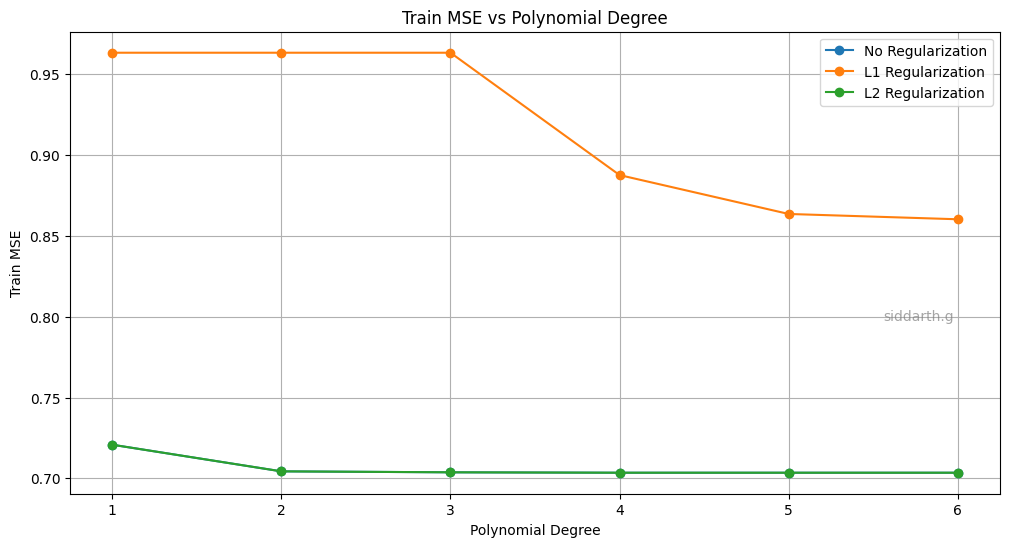

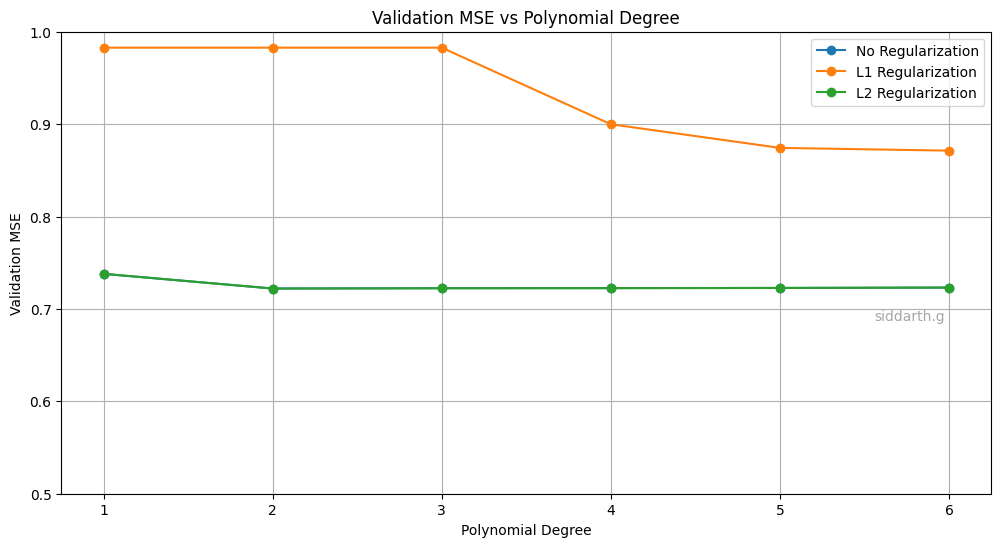

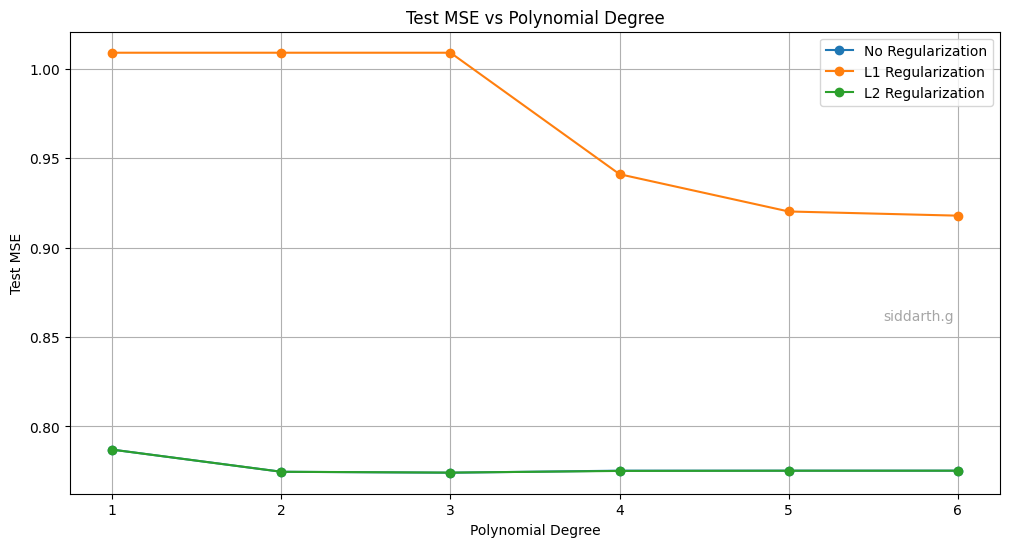

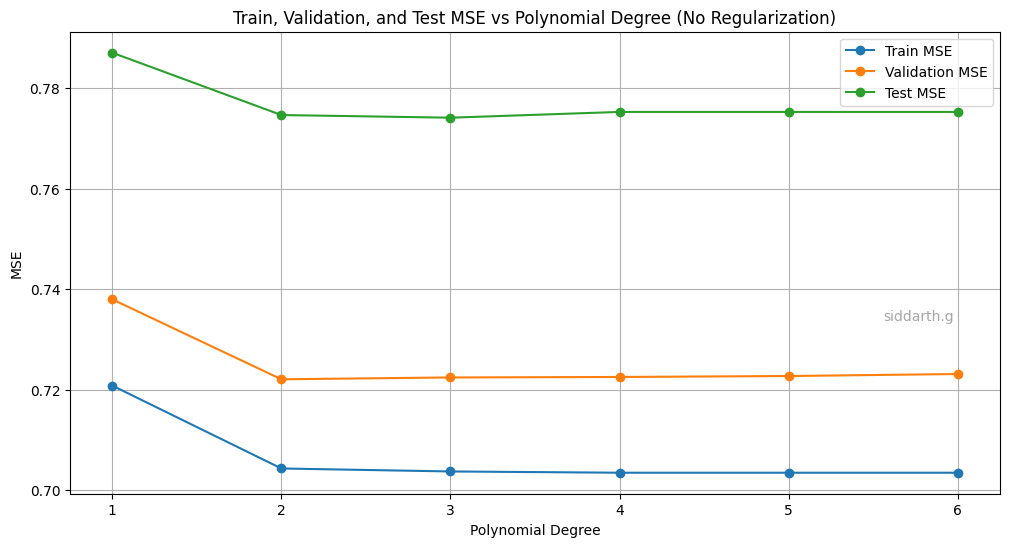

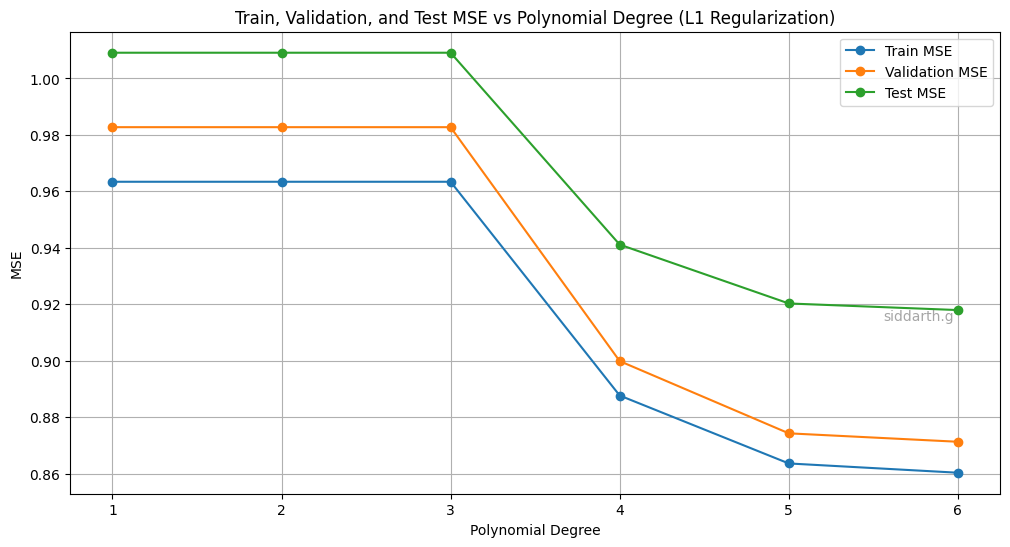

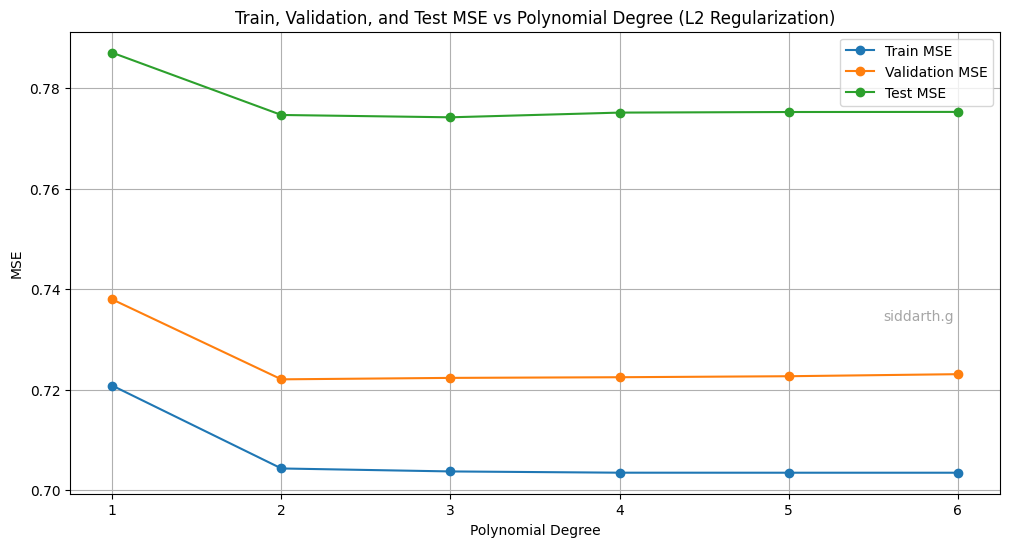

As the degree increases, the MSE for L1 regularization tends to decrease. It saturates for L2 and no regularization, at a lower value than L1. However, when we observe the trend on the validation set, no regularization for higher degree polynomials gives us massive overfitting. This causes the MSE to shoot up drastically. L1 and L2 perform relatively similar to the Train set itself.
Best (Degree: 2, Strength: 0.001) for None Regularization : 0.7220721718213008
Best (Degree: 6, Strength: 0.0071968567300115215) for l1 Regularization : 0.7170327689473421
Best (Degree: 4, Strength: 138.9495494373136) for l2 Regularization : 0.7219760753054402


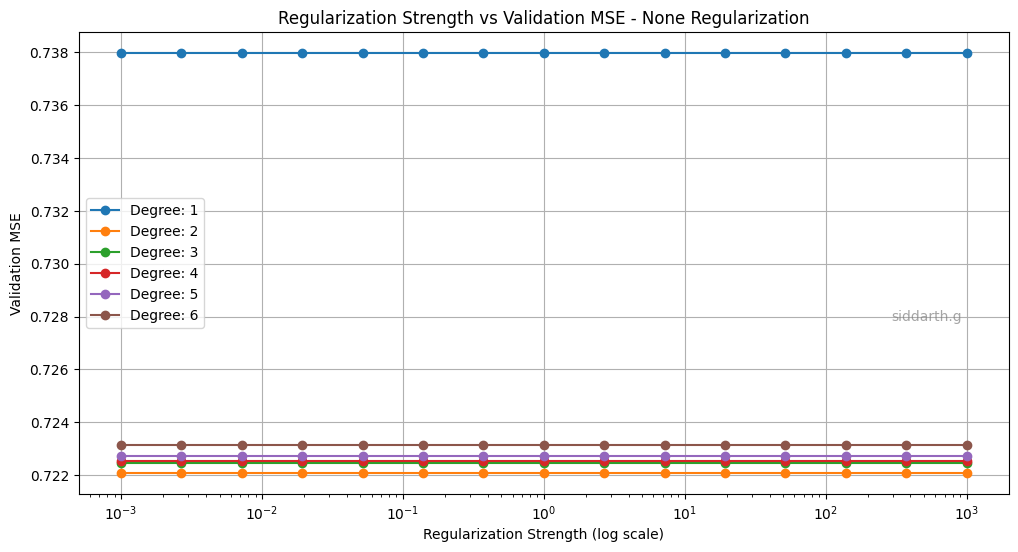

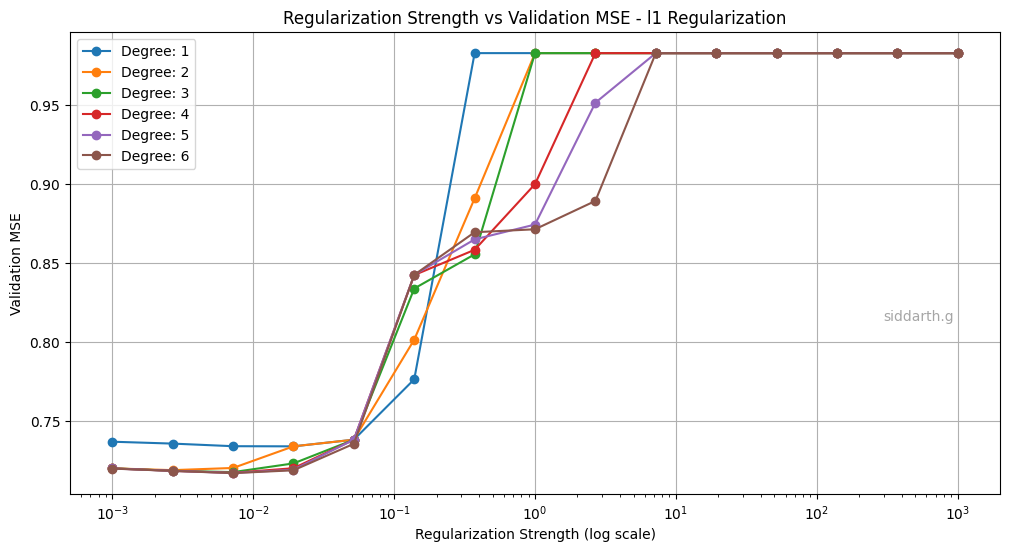

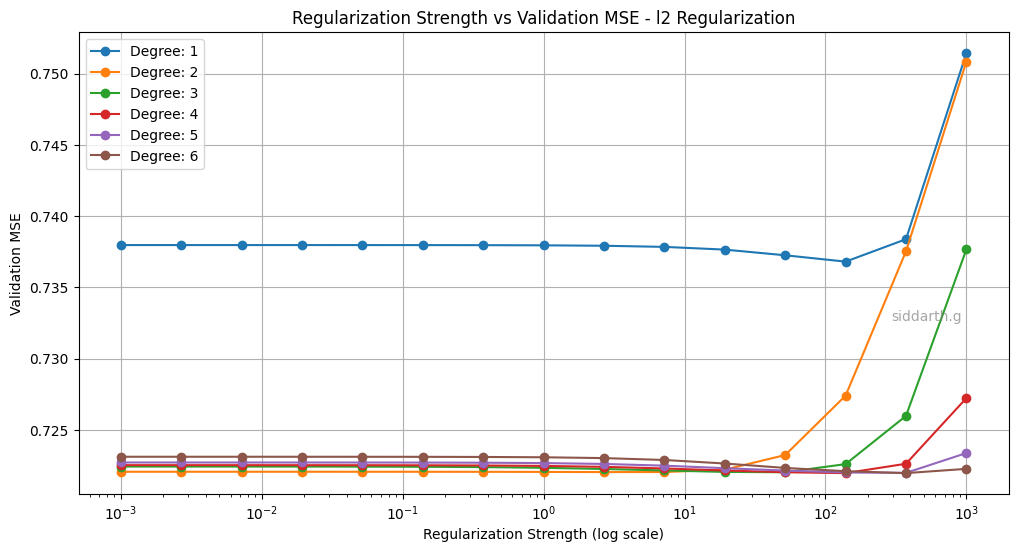

There is no effect of regularizer strength on the no regularization setup. Thus, we see the graph to be giving us constant MSE. However, with L1 and L2 regularization, we observe a change. The MSE is the least for small values of regularization strength. As we increase the regularization strength, the MSE also increases. Compared to the previous results where the regularization strength was set to 1 by default, we do observe an improvement in the validation MSE. The overall setup that yielded the best performance was the L1 regularization with a degree of 6 and regularization strength 0.01, with an MSE of 0.7169 on the validation set. On the Test set, it gives us an MSE of 0.7714, which is the least!
L1 Best Setup Results:
  Degree: 6
  Regulariser: l1
  Regulariser_Strength: 0.01
  Train_MSE: 0.707038073075669
  Val_MSE: 0.716912728192522
  Test_MSE: 0.7714528886300036
  Coefficients: [Array of length 3003]
Coefficients (0-based indexing):
  Feature 1: 0.9468832513433114
  Feature 128

In [35]:
if __name__ == "__main__":

    # Generating a personalized random seed
    username = "siddarth.g"
    seed = int(hashlib.sha256(username.encode()).hexdigest(), 16) % (2**32)
    print("Seed value : ", seed)
    print_separator()

    dataset = StudentDataset(num_students=10000, seed=seed, username=username)
    df = dataset.get_full_dataframe()
    print("Student Dataset size: ", df.shape)
    print(df.head())
    print(" .....")
    print(df.tail())
    print_separator()

    Regressor_obj = Regressor(df, username, seed)
    regression_setups = [None, "l1", "l2"]
    degrees = range(1, 7)

    results = Regressor_obj.print_data(regression_setups, degrees)
    Regressor_obj.plot_poly_deg_vs_mse(results)
    print("As the degree increases, the MSE for L1 regularization tends to decrease. It saturates for L2 and no regularization, at a lower value than L1. However, when we observe the trend on the validation set, no regularization for higher degree polynomials gives us massive overfitting. This causes the MSE to shoot up drastically. L1 and L2 perform relatively similar to the Train set itself.")
    print_separator()

    Regressor_obj.plot_reg_strength_vs_mse(regression_setups, degrees)
    print("There is no effect of regularizer strength on the no regularization setup. Thus, we see the graph to be giving us constant MSE. However, with L1 and L2 regularization, we observe a change. The MSE is the least for small values of regularization strength. As we increase the regularization strength, the MSE also increases. Compared to the previous results where the regularization strength was set to 1 by default, we do observe an improvement in the validation MSE. The overall setup that yielded the best performance was the L1 regularization with a degree of 6 and regularization strength 0.01, with an MSE of 0.7169 on the validation set. On the Test set, it gives us an MSE of 0.7714, which is the least!")
    print_separator()

    # Retrieve the values for the best setup L1
    l1_best_setup = ("l1", 6, 0.01)
    best = Regressor_obj.run_poly_regression(regularizer=l1_best_setup[0], reg_strength=l1_best_setup[2], degree=l1_best_setup[1])
    print("L1 Best Setup Results:")
    for key, value in best.items():
        if key == "Coefficients":
            print(f"  {key}: [Array of length {len(value)}]")
        else:
            print(f"  {key}: {value}")

    print("Coefficients (0-based indexing):")
    for i, coef in enumerate(best["Coefficients"]):
        if coef != 0:
            print(f"  Feature {i}: {coef}")
    print()

    print("There are only 5 non-zero coefficients. These are the intercept and 4 non-linear features. We are encoding the final feature matrix as \"Major\": \"ordinal\", \"Program\": \"onehot\", \"Gender\": \"onehot\", thus, there are 8 features in total. Using a look up table, I found that the features are: ")
    print("x1 : (Major)")
    print("x1 ^ 6 : (Major^6)")
    print("x1 ^ 5 * x4 : (Major^5 * Program[CSE])")
    print("x1 ^ 5 * x5 : (Major^5 * Program[ECE])")
    print("x1 ^ 5 * x6 : (Major^5 * Gender[Female])")
    print_separator()

    print("If we look at L2, the best setup is Degree 4, Regularization Strength 100, with an MSE of 0.722 on teh validation set. On the test set, it gives us an MSE of 0.7746!")
    l2_best_setup = ("l2", 4, 100)
    best = Regressor_obj.run_poly_regression(regularizer=l2_best_setup[0], reg_strength=l2_best_setup[2], degree=l2_best_setup[1])
    print("L2 Best Setup Results:")
    for key, value in best.items():
        if key == "Coefficients":
            print(f"  {key}: [Array of length {len(value)}]")
        else:
            print(f"  {key}: {value}")

    print("Coefficients (0-based indexing):")
    cnt = 0
    for i, coef in enumerate(best["Coefficients"]):
        if coef != 0:
            cnt += 1
            # print(f"  Feature {i}: {coef}")
    print()

    print(f"There are {cnt} non-zero coefficients.")
    print_separator()

    print("The most important predictors of GPA are the Major and its functions. This is verified from our generation of GPAs based on program. For L1 regularization, the number of non-zero features are significantly lower than L2 regularization and also for a lower MSE value. This is because L1 regularization tends to produce sparser models, effectively selecting a subset of features that contribute the most to the prediction.")
    print_separator()

    print("Thus, the best setup we found on the validation set is L1 Regularization with Degree 6 and Regularization Strength 0.01. This also gives us the least MSE on the Test dataset, which is 0.7714!")
    print_separator()
